<a href="https://colab.research.google.com/github/Mehtabul-Islam/CSE330---numerical-methods/blob/main/LAB%2004/Newton's_Divided_Difference_Method_for_Interpolation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Make sure you remove `raise NotImplementedError()` and fill in any place that says `# YOUR CODE HERE`, as well as your `NAME`, `ID`, and `SECTION` below:

In [1]:
NAME = "Md Mehtabul Islam"
ID = "24301400"
SECTION = "14"

---

## Part 2: Polynomial Interpolation Using Newton's Divided Difference Form
---


### Newton's Divided Difference Form

Newton form of a $n$ degree polynomial:

$$p_n(x) = \sum_{k=0}^{n} a_kn_k(x),$$
where the basis is:
$$n_k(x) = \prod_{j=0}^{k-1}(x-x_j),$$
$$ n_0(x)=1,$$

and the coefficients are: $$a_k = f[x_0, x_1, ..., x_k],$$

where the notation $f[x_0, x_1,\dots,x_k]$ denotes the divided difference.

By expanding the Newton form, we get:

$$p(x) = f [x_0] + (x-x_0) f[x_0,x_1] + (x-x_0) (x-x_1) f[x_0,x_1,x_2] + \dots + (x-x_0) (x-x_1) \dots (x-x_{k-1}) f[x_0, x_1, \dots, x_k]$$


## Task 2 - 2 Marks:
1. Complete the `calc_div_diff(x,y)` function which takes input `x` and `y`, and calculates all the divided differences. You may use the lambda function `difference()` inside the `calc_div_diff(x,y)` function to calculate the divided differences.

2. Complete the `__call__()` function which takes an input `x`, and calculates `y` using all the difference coefficients. `x` can be a single value or a numpy. In this case, it is a numpy array.

`res` variable must contain all results (corresponding y for x).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from numpy.polynomial import Polynomial

In [3]:
class Newtons_Divided_Differences:

    def __init__(self, data_x, differences):
        self.data_x = data_x
        self.differences = differences

    def __call__(self, x):
        '''
        this function is for calculating y from given x using all the difference coefficients
        x can be a single value or a numpy
        the formula being used:
        f(x) = f [x0] + (x-x0) f[x0,x1] + (x-x0) (x-x1) f[x0,x1,x2] + . . . + (x-x0) (x-x1) . . . (x-xk-1) f[x0, x1, . . ., xk]

        work on this after implementing 'calc_div_diff'. Then you should have
        f[x0], f[x0,x1]. . . . . ., f[x0, x1, . . ., xk] stored in self.differences

        'res' variable must return all the results (corresponding y for x)
        '''

        res = np.zeros(len(x)) #Initialization to avoid runtime error. You can change this line if you wish

        #----------------------------------------------
        # YOUR CODE HERE
        #raise NotImplementedError()
        #----------------------------------------------
        res = []
        for x_i in x:
            sum = 0
            for col in range(len(self.differences)):
                f = self.differences[0][col]
                prod = 1
                for i in range(col):
                    prod *= (x_i-data_x[i])

                r = prod*f
                sum += r
            res.append(sum)
        return res

In [4]:
# basic rule for calculating the difference, implanted in the lambda function.
# You may use it if you wish
difference = lambda y2, y1, x2, x1: (y2-y1)/(x2-x1)

def calc_div_diff(x,y):
    assert(len(x)==len(y))
    #write this function to calculate all the divided differences in the list 'b'
    b = []  #initializing
    #----------------------------------------------
    # YOUR CODE HERE
    b = np.zeros((len(x), len(x)))

    b[:,0] = y

    for c in range(1, len(x)):
        for r in range(0, len(x)-c):
            b[r][c] = (b[r+1][c-1]-b[r][c-1])/(x[r+c]-x[r])
    print(b)
    #----------------------------------------------
    return b

In [5]:
data_x = [-3.,-2.,-1.,0.,1.,3.,4.]
data_y = [-60.,-80.,6.,1.,45.,30.,16.]

test = calc_div_diff(data_x, data_y)

assert len(test) == len(data_x)

[[-60.         -20.          53.         -32.83333333  14.04166667
   -3.46527778   0.72321429]
 [-80.          86.         -45.5         23.33333333  -6.75
    1.59722222   0.        ]
 [  6.          -5.          24.5        -10.41666667   2.83333333
    0.           0.        ]
 [  1.          44.         -17.16666667   3.75         0.
    0.           0.        ]
 [ 45.          -7.5         -2.16666667   0.           0.
    0.           0.        ]
 [ 30.         -14.           0.           0.           0.
    0.           0.        ]
 [ 16.           0.           0.           0.           0.
    0.           0.        ]]


### Plotting the polynomial
* `data_x` and `data_y` are the coordinates of the given nodes.

* `differences` is a list which contains the divided differences as each of its elements: $f[x_0], f[x_0,x_1], f[x_0,x_1,x_2], \dots$

* `obj` is an object of type `Newtons_Divided_Differences`. Creating the object runs the constructor of the class where the `difference` are stored in `self.differences`.

* `X` contains $x_i$ values through which we want to plot our polynomial.

* Calling the object using `obj(X)` executes the `__call__()` function of the class, which returns a numpy array containing the corresponding $y_i$ values, and storing them in variable `F`.

* Using `plt.plot(X,F)`, we plot the $(x_i, y_i)$ pairs of the polynomial.

[[-3.00000000e+01 -5.00000000e+00  3.93333333e+01 -2.86060606e+01
   6.57892652e+00 -8.43651555e-01  8.65809514e-02]
 [-5.00000000e+01  1.72000000e+02 -1.18000000e+02  2.73148148e+01
  -3.54489214e+00  3.68481765e-01  0.00000000e+00]
 [ 3.60000000e+01 -5.00000000e+00  4.91666667e+00 -1.04432234e+00
   1.39925503e-01  0.00000000e+00  0.00000000e+00]
 [ 3.10000000e+01  1.46666667e+01 -2.91575092e+00  2.84969932e-01
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 7.50000000e+01 -4.28571429e+00 -4.93506494e-01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 6.00000000e+01 -7.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 4.60000000e+01  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]]


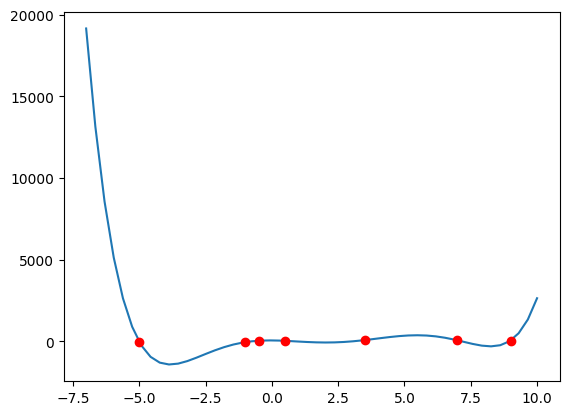

In [6]:
import numpy as np
import matplotlib.pyplot as plt

data_x = np.array([-5.,-1,-0.5,0.5,3.5,7.,9])
data_y = np.array([-30., -50., 36., 31., 75., 60., 46.])
differences = calc_div_diff(list(data_x), list(data_y))
p = Newtons_Divided_Differences(data_x, list(differences))
test_x = np.linspace(-7, 10, 50, endpoint=True)
test_y = p(test_x)

plt.plot(test_x, test_y)
plt.plot(data_x, data_y, 'ro')
plt.show()

# Daily Evaluation - 4 marks

[[ 3.75       -1.265       0.85201812]
 [ 1.22        1.43589744  0.        ]
 [ 2.9         0.          0.        ]]


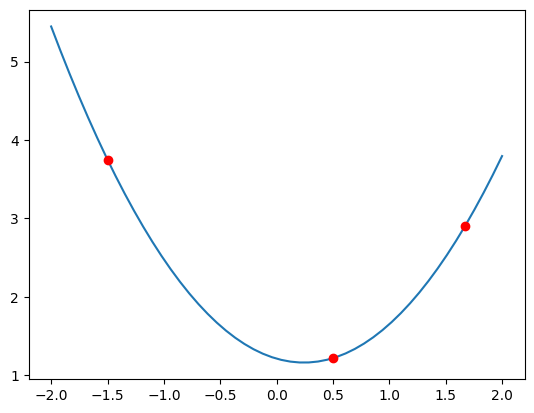

In [10]:
data_x = np.array([-1.5, 0.5, 1.67])
data_y = np.array([3.75, 1.22, 2.9])
x = [0.25, 0.50, 0.75]

#test = calc_div_diff(x_data, y_data)
#assert len(test) == len(x_data)

differences = calc_div_diff(list(data_x), list(data_y))
p = Newtons_Divided_Differences(x, list(differences))
test_x = np.linspace(-2, 2, 50, endpoint=True)
test_y = p(test_x)

plt.plot(test_x, test_y)
plt.plot(data_x, data_y, 'ro')
plt.show()